<a href="https://colab.research.google.com/github/adhithya2525/adhi-15day-workshop/blob/main/Day2/mini_project_Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('Student Performance.csv')
print(df.columns.to_list())

['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


In [ ]:
conn= sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql('student_performance',conn,if_exists='replace',index=False)
cursor.execute("SELECT COUNT(*) FROM student_performance")
count=cursor.fetchone()[0]
print(f"Number of rows in the table: {count}")

Number of rows in the table: 30


In [ ]:
def run_query(sql_string, description_label):
    print(f"\n--- {description_label} ---")
    query_df = pd.read_sql_query(sql_string, conn)
    display(query_df)
    print(f"Rows returned: {len(query_df)}")

In [ ]:
query7 = """SELECT department,
       AVG(attendance_percentage) AS avg_attendance
FROM student_performance
GROUP BY department
ORDER BY avg_attendance DESC"""
run_query(query7, "Average Attendance Percentage by Department")


--- Average Attendance Percentage by Department ---


,department,avg_attendance
0,Computer Science,90.692308
1,Mechanical,83.500000
2,Electronics,80.333333
3,Civil,74.600000


Rows returned: 4



--- Top 8 Students by Total Score ---


,name,total_score
0,Ananya Das,371
1,Tanvi Mehta,367
2,Akanksha Yadav,365
3,Arjun Nair,356
4,Divya Singh,356
5,Swati Kulkarni,354
6,Amit Bose,336
7,Suresh Rao,334


Rows returned: 8


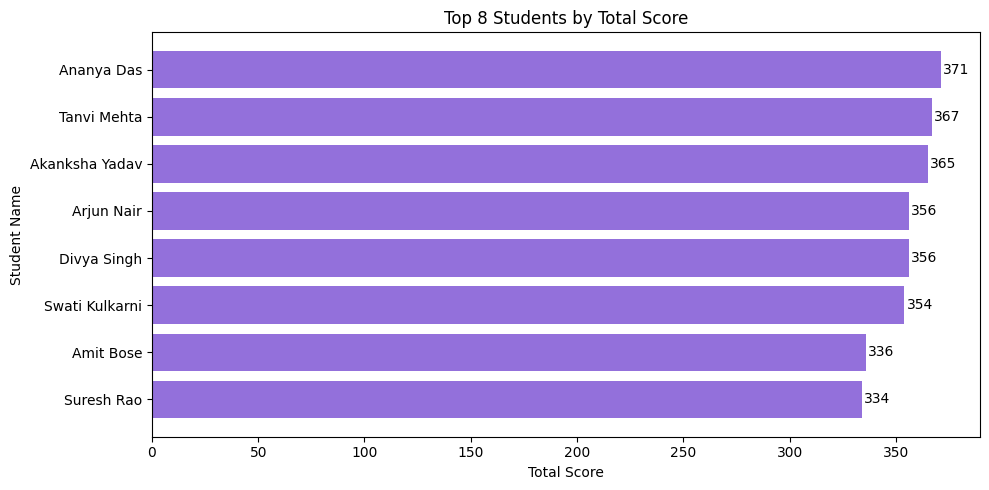


--- Average Attendance by Gender ---


,gender,avg_attendance
0,Female,88.533333
1,Male,80.466667


Rows returned: 2


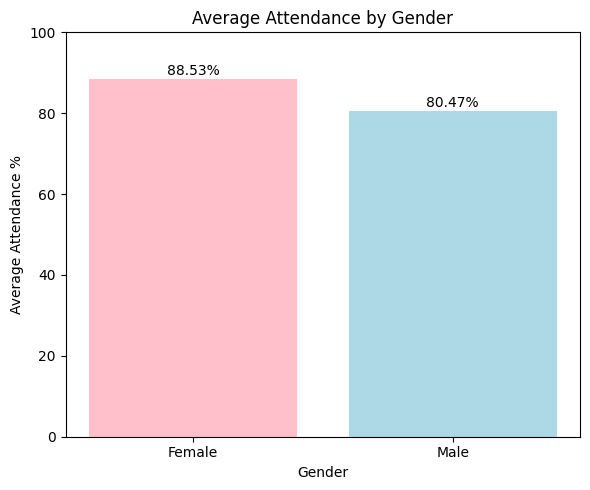

In [ ]:
query_top_students = """
SELECT name,
       (math_score + science_score + english_score + programming_score) AS total_score
FROM student_performance
ORDER BY total_score DESC
LIMIT 8
"""
query_gender_attn = """
SELECT gender,
       AVG(attendance_percentage) AS avg_attendance
FROM student_performance
GROUP BY gender
"""
run_query(query_top_students, "Top 8 Students by Total Score")
top_df = pd.read_sql_query(query_top_students, conn)
plt.figure(figsize=(10, 5))
plt.barh(top_df['name'], top_df['total_score'], color='mediumpurple')
plt.xlabel('Total Score')
plt.ylabel('Student Name')
plt.title('Top 8 Students by Total Score')
plt.gca().invert_yaxis()
for i, val in enumerate(top_df['total_score']):
    plt.text(val + 1, i, str(val), va='center')
plt.tight_layout()
plt.show()

run_query(query_gender_attn, "Average Attendance by Gender")

# Visualize Attendance by Gender
gender_df = pd.read_sql_query(query_gender_attn, conn)
plt.figure(figsize=(6, 5))
plt.bar(gender_df['gender'], gender_df['avg_attendance'], color=['pink', 'lightblue'])
plt.ylabel('Average Attendance %')
plt.xlabel('Gender')
plt.title('Average Attendance by Gender')
plt.ylim(0, 100)
for i, val in enumerate(gender_df['avg_attendance']):
    plt.text(i, val + 1, f"{val:.2f}%", ha='center')
plt.tight_layout()
plt.show()


--- Top 8 Students by Total Score ---


,name,total_score
0,Ananya Das,371
1,Tanvi Mehta,367
2,Akanksha Yadav,365
3,Arjun Nair,356
4,Divya Singh,356
5,Swati Kulkarni,354
6,Amit Bose,336
7,Suresh Rao,334


Rows returned: 8


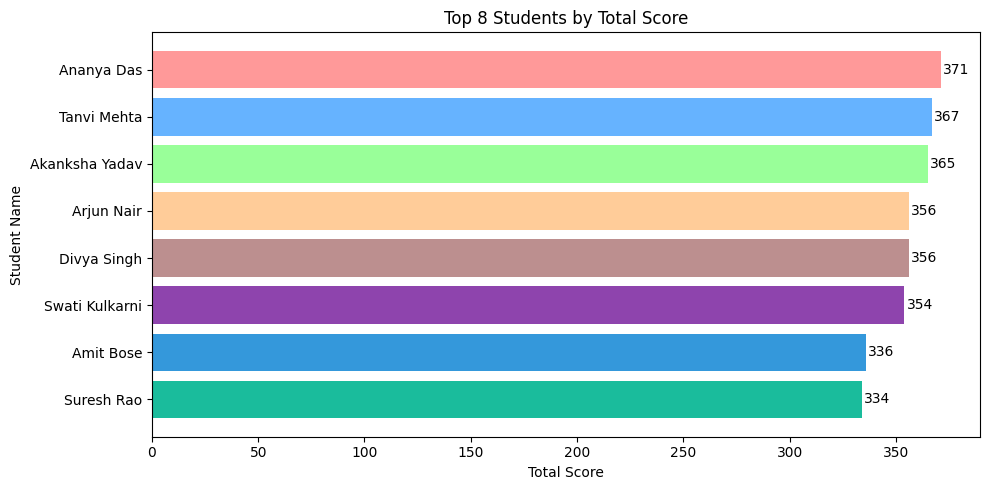


--- Average Attendance by Gender ---


,gender,avg_attendance
0,Female,88.533333
1,Male,80.466667


Rows returned: 2


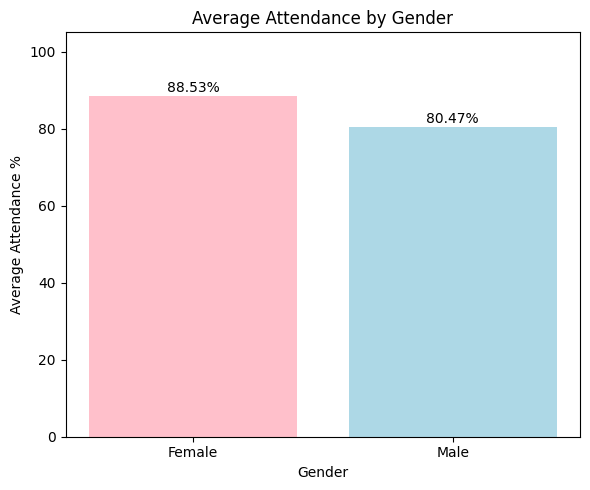

In [ ]:
top_student_colors = ['#FF9999', '#66B3FF', '#99FF99', '#FFCC99', '#BC8F8F', '#8E44AD', '#3498DB', '#1ABC9C']
gender_colors = ['#FFC0CB', '#ADD8E6']

query_top_students = """
SELECT name,
       (math_score + science_score + english_score + programming_score) AS total_score
FROM student_performance
ORDER BY total_score DESC
LIMIT 8
"""
run_query(query_top_students, "Top 8 Students by Total Score")


top_df = pd.read_sql_query(query_top_students, conn)
plt.figure(figsize=(10, 5))
plt.barh(top_df['name'], top_df['total_score'], color=top_student_colors)
plt.xlabel('Total Score')
plt.ylabel('Student Name')
plt.title('Top 8 Students by Total Score')
plt.gca().invert_yaxis()

for i, val in enumerate(top_df['total_score']):
    plt.text(val + 1, i, str(val), va='center')

plt.tight_layout()
plt.show()

query_gender_attn = """
SELECT gender,
       AVG(attendance_percentage) AS avg_attendance
FROM student_performance
GROUP BY gender
"""
run_query(query_gender_attn, "Average Attendance by Gender")

gender_df = pd.read_sql_query(query_gender_attn, conn)
plt.figure(figsize=(6, 5))
plt.bar(gender_df['gender'], gender_df['avg_attendance'], color=gender_colors)
plt.ylabel('Average Attendance %')
plt.xlabel('Gender')
plt.title('Average Attendance by Gender')
plt.ylim(0, 105)

for i, val in enumerate(gender_df['avg_attendance']):
    plt.text(i, val + 1, f"{val:.2f}%", ha='center')

plt.tight_layout()
plt.show()

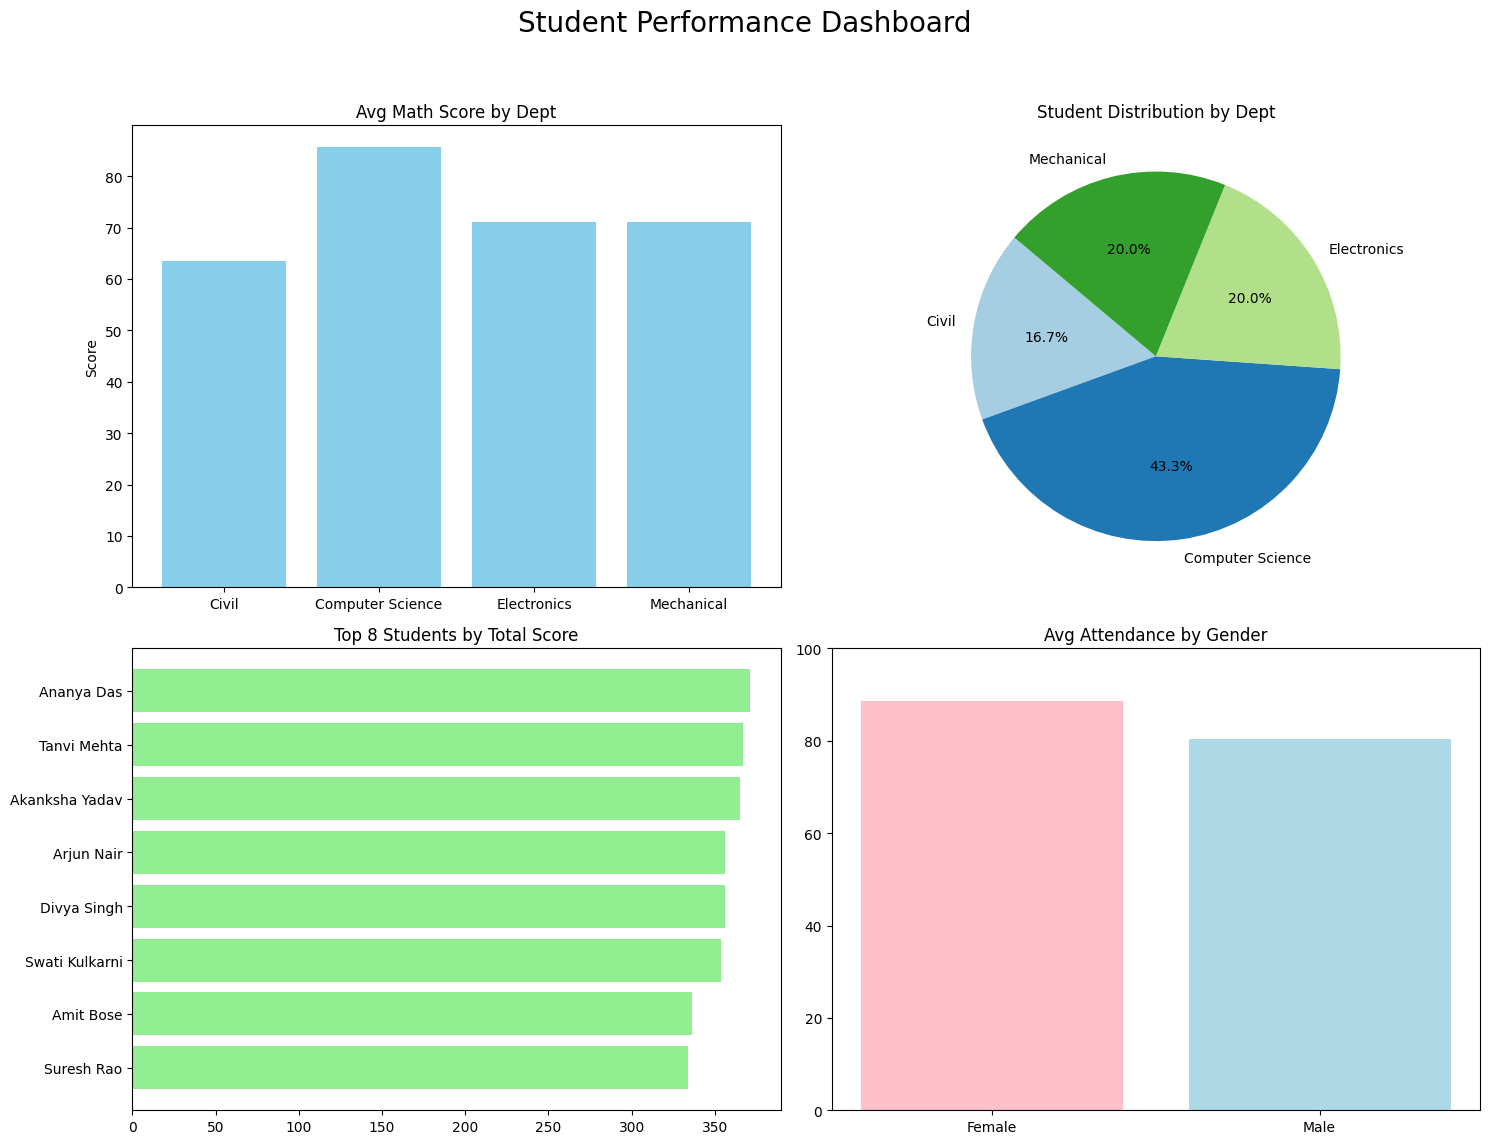


--- PRACTICE QUESTION ANSWERS ---

Q1: SQL for average programming score for females:
   AVG(programming_score)
0                    70.2

Q2: WHERE vs HAVING
WHERE filters rows before grouping. HAVING filters groups after GROUP BY.
Example WHERE: SELECT * FROM student_performance WHERE age > 20
Example HAVING: SELECT department FROM student_performance GROUP BY department HAVING COUNT(*) > 5

Q3: Depts with avg attendance > 85%:
         department   avg_attn
0  Computer Science  90.692308

Q4: pd.read_sql_query()
It returns a pandas DataFrame. It requires: 1) A SQL query string, and 2) A database connection object.

Q5: Modifying Panel 1 to show Programming scores instead of Math:


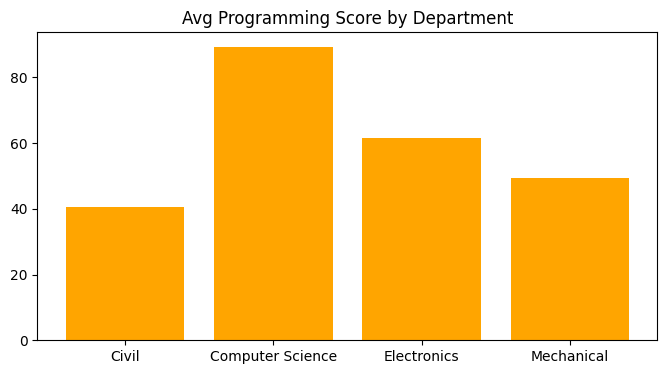

In [ ]:

query_p1 = "SELECT department, AVG(math_score) as avg_math FROM student_performance GROUP BY department"
df_p1 = pd.read_sql_query(query_p1, conn)

query_p2 = "SELECT department, COUNT(*) as student_count FROM student_performance GROUP BY department"
df_p2 = pd.read_sql_query(query_p2, conn)

query_p3 = """
SELECT name, (math_score + science_score + english_score + programming_score) AS total_score
FROM student_performance
ORDER BY total_score DESC
LIMIT 8
"""
df_p3 = pd.read_sql_query(query_p3, conn)

# 4. Gender-wise average attendance
query_p4 = "SELECT gender, AVG(attendance_percentage) as avg_attendance FROM student_performance GROUP BY gender"
df_p4 = pd.read_sql_query(query_p4, conn)

# --- MATPLOTLIB DASHBOARD ---

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Student Performance Dashboard', fontsize=20)

# Panel 1: Avg Math by Department
axes[0, 0].bar(df_p1['department'], df_p1['avg_math'], color='skyblue')
axes[0, 0].set_title('Avg Math Score by Dept')
axes[0, 0].set_ylabel('Score')

# Panel 2: Student Count Pie Chart
axes[0, 1].pie(df_p2['student_count'], labels=df_p2['department'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
axes[0, 1].set_title('Student Distribution by Dept')

# Panel 3: Top 8 Students (Horizontal)
axes[1, 0].barh(df_p3['name'], df_p3['total_score'], color='lightgreen')
axes[1, 0].set_title('Top 8 Students by Total Score')
axes[1, 0].invert_yaxis()

# Panel 4: Gender Avg Attendance
axes[1, 1].bar(df_p4['gender'], df_p4['avg_attendance'], color=['pink', 'lightblue'])
axes[1, 1].set_title('Avg Attendance by Gender')
axes[1, 1].set_ylim(0, 100)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- PRACTICE QUESTIONS ---

print("\n--- PRACTICE QUESTION ANSWERS ---")

# Q1
print("\nQ1: SQL for average programming score for females:")
q1_sql = "SELECT AVG(programming_score) FROM student_performance WHERE gender = 'Female'"
print(pd.read_sql_query(q1_sql, conn))

# Q2
print("\nQ2: WHERE vs HAVING")
print("WHERE filters rows before grouping. HAVING filters groups after GROUP BY.")
print("Example WHERE: SELECT * FROM student_performance WHERE age > 20")
print("Example HAVING: SELECT department FROM student_performance GROUP BY department HAVING COUNT(*) > 5")

# Q3
print("\nQ3: Depts with avg attendance > 85%:")
q3_sql = "SELECT department, AVG(attendance_percentage) as avg_attn FROM student_performance GROUP BY department HAVING avg_attn > 85"
print(pd.read_sql_query(q3_sql, conn))

# Q4
print("\nQ4: pd.read_sql_query()")
print("It returns a pandas DataFrame. It requires: 1) A SQL query string, and 2) A database connection object.")

# Q5
print("\nQ5: Modifying Panel 1 to show Programming scores instead of Math:")
query_p1_mod = "SELECT department, AVG(programming_score) as avg_prog FROM student_performance GROUP BY department"
df_p1_mod = pd.read_sql_query(query_p1_mod, conn)
plt.figure(figsize=(8, 4))
plt.bar(df_p1_mod['department'], df_p1_mod['avg_prog'], color='orange')
plt.title('Avg Programming Score by Department')
plt.show()